# BTC 15-Min Gap Strategy (leak-free)
**One job:** predict each 15-min window's direction using ONLY data available BEFORE the window opens (frozen prediction), then compare that to the live Kalshi crowd price during the window. Trade when they disagree enough, persistently, in the early minutes.

**Why the old version showed 84%:** the model prediction was leaking information from inside the window it was trying to predict (lookahead). This version freezes each window's prediction at its open time, so no future info leaks in. Expect HONEST (~50%) numbers — a real 52% beats a fake 84%.

## 1 · Config

In [1]:
import math, time, calendar, requests, os
import time as _t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import kalshi_history as kh

# ── Strategy knobs ──
EDGE_THRESHOLD = 0.04
PERSIST_MINS   = 2
MIN_MINUTE     = 2
MAX_MINUTE     = 9

# ── Model knobs ──
VOL_LOOKBACK   = 10      # candles for volatility (before each window)
TRAIN_SPLIT    = 0.70    # split WITHIN the flow-having range
EPOCHS         = 5000
LR             = 0.01

# ── Costs / capital ──
KALSHI_FEE_MULT= 0.07
INIT_CAPITAL   = 100.0

# ── Data ──
SYMBOL         = "BTC-USD"
GRANULARITY    = "FIFTEEN_MINUTE"
CANDLE_SECONDS = 900
TARGET_MARKETS = 2000    # how many Kalshi markets to pull (≈ 2000/96 ≈ 20 days)
LEAD_IN_BARS   = 40      # small Coinbase lead-in ONLY so volatility has history

# ── CACHING ──
# First run downloads + saves to these CSVs. Later runs LOAD them (no API).
# Set REFRESH=True to force a fresh download.
REFRESH        = False
CACHE_CROWD    = "cache_kalshi_crowd.csv"   # minute-by-minute crowd prices + settle
CACHE_FLOW     = "cache_kalshi_flow.csv"    # per-window order-flow imbalance
CACHE_BTC      = "cache_btc_candles.csv"    # Coinbase candles (same date range)

print("config loaded — caching ON" + ("  (REFRESH forced)" if REFRESH else ""))
print(f"target Kalshi markets: {TARGET_MARKETS} (~{TARGET_MARKETS//96} days)")

config loaded — caching ON
target Kalshi markets: 2000 (~20 days)


## 2 · Kalshi Data (pulled first, paginated, cached)
*Pull many past KXBTC15M markets (paginated), their minute-by-minute crowd prices, AND the per-window order flow. Cached to CSV — first run downloads, later runs load instantly. Kalshi's range sets the period; Coinbase matches it next.*

In [2]:
if (not REFRESH) and os.path.exists(CACHE_CROWD) and os.path.exists(CACHE_FLOW):
    mkt_df = pd.read_csv(CACHE_CROWD)
    flow_df = pd.read_csv(CACHE_FLOW)
    flow_by_open = dict(zip(flow_df["open_unix"], flow_df["flow"]))
    print(f"LOADED from cache: {len(mkt_df)} crowd rows, {len(flow_by_open)} flow windows (no API calls)")
else:
    cutoff = kh.get_cutoff(); print("kalshi cutoff:", cutoff.get("market_settled_ts"))
    # ── paginate the markets list to TARGET_MARKETS ──
    markets=[]; cursor=None
    while len(markets) < TARGET_MARKETS:
        resp = kh.list_historical_markets(series="KXBTC15M", limit=200, cursor=cursor)
        batch = resp.get("markets", [])
        if not batch: break
        markets += batch
        cursor = resp.get("cursor")
        if not cursor: break
        _t.sleep(0.3)
    print(f"markets pulled: {len(markets)}")

    def parse_utc(s): return calendar.timegm(_t.strptime(s[:19], "%Y-%m-%dT%H:%M:%S"))
    def implied_prob(c):
        pr=c.get("price",{})
        for k in ("mean","mean_dollars"):
            if pr.get(k) not in (None,"","0","0.0000"): return float(pr[k])
        yb=c.get("yes_bid",{}); ya=c.get("yes_ask",{})
        ybc=yb.get("close",yb.get("close_dollars")); yac=ya.get("close",ya.get("close_dollars"))
        if ybc is not None and yac is not None: return (float(ybc)+float(yac))/2.0
        return None

    rows=[]; flow_by_open={}
    print(f"pulling candles + flow for {len(markets)} markets (slow, one-time)...")
    for i,m in enumerate(markets):
        tkr=m.get("ticker"); result=(m.get("result") or "").lower()
        if not tkr or result not in ("yes","no"): continue
        try:
            ou=parse_utc(m["open_time"])//CANDLE_SECONDS*CANDLE_SECONDS
            cu=parse_utc(m["close_time"])
        except Exception: continue
        # crowd candlesticks
        try:
            cs=kh.get_historical_candlesticks(tkr,ou,cu,period_interval=1).get("candlesticks",[])
            for c in cs:
                ip=implied_prob(c)
                if ip is not None:
                    rows.append({"ticker":tkr,"open_unix":ou,"end_ts":int(c.get("end_period_ts",0)),
                                 "crowd_prob":ip,"settle":1 if result=="yes" else 0})
        except Exception as ex:
            pass
        # order flow during this window
        try:
            trades=kh.get_market_trades(tkr, min_ts=ou, max_ts=cu, limit=1000, max_pages=5)
            flow_by_open[ou]=kh.flow_imbalance(trades)
        except Exception:
            flow_by_open[ou]=0.0
        if i%50==0: print(f"  {i}/{len(markets)}, {len(rows)} crowd rows")
        _t.sleep(0.4)

    mkt_df=pd.DataFrame(rows)
    flow_df=pd.DataFrame([{"open_unix":k,"flow":v} for k,v in flow_by_open.items()])
    mkt_df.to_csv(CACHE_CROWD,index=False); flow_df.to_csv(CACHE_FLOW,index=False)
    print(f"SAVED cache: {len(mkt_df)} crowd rows, {len(flow_by_open)} flow windows")

KALSHI_MIN_TS=int(mkt_df["open_unix"].min()); KALSHI_MAX_TS=int(mkt_df["open_unix"].max())
print(f"Kalshi range: {pd.to_datetime(KALSHI_MIN_TS,unit='s',utc=True)} -> {pd.to_datetime(KALSHI_MAX_TS,unit='s',utc=True)}")
print(f"unique Kalshi windows: {mkt_df['open_unix'].nunique()}")

LOADED from cache: 29998 crowd rows, 2000 flow windows (no API calls)
Kalshi range: 2026-03-12 18:45:00+00:00 -> 2026-04-02 23:30:00+00:00
unique Kalshi windows: 2000


## 3 · Coinbase Data + Model (matched 1:1 to Kalshi range)
*Pull Coinbase BTC for the SAME date range as the Kalshi data (one-to-one on dates), plus a tiny lead-in so volatility has history. Features: volatility (Coinbase) + flow (Kalshi). Train AND test both INSIDE the flow-having range, so flow is never absent → it actually gets used. Cached.*

In [3]:
# Coinbase pull matched to Kalshi range (+ tiny lead-in for volatility)
btc_start = KALSHI_MIN_TS - LEAD_IN_BARS*CANDLE_SECONDS
btc_end   = KALSHI_MAX_TS + CANDLE_SECONDS

if (not REFRESH) and os.path.exists(CACHE_BTC):
    df = pd.read_csv(CACHE_BTC)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    print(f"LOADED {len(df)} BTC candles from cache")
else:
    def download_btc(start_ts, end_ts):
        url=f"https://api.coinbase.com/api/v3/brokerage/market/products/{SYMBOL}/candles"
        rows=[]; end=end_ts
        while end>start_ts:
            start=max(end-300*CANDLE_SECONDS, start_ts)
            r=requests.get(url,params={"start":str(int(start)),"end":str(int(end)),
                           "granularity":GRANULARITY,"limit":300},timeout=15)
            r.raise_for_status(); rows+=r.json().get("candles",[]); end=start; _t.sleep(0.25)
        d=pd.DataFrame(rows)[["start","close","volume"]]
        d["start"]=pd.to_datetime(d["start"].astype(int),unit="s",utc=True)
        d["close"]=d["close"].astype(float); d["volume"]=d["volume"].astype(float)
        d=d.rename(columns={"start":"timestamp"}).sort_values("timestamp").drop_duplicates("timestamp").reset_index(drop=True)
        return d[d["close"]>0].reset_index(drop=True)
    df = download_btc(btc_start, btc_end)
    df.to_csv(CACHE_BTC, index=False)
    print(f"SAVED {len(df)} BTC candles to cache")
print(f"BTC range: {df.timestamp.min()} -> {df.timestamp.max()}")

# ── FEATURE 1: volatility (pre-window) ──
df["log_return"]=np.log(df["close"]/df["close"].shift(1))
df["volatility"]=df["log_return"].rolling(VOL_LOOKBACK).std().shift(1)
_secs=df["timestamp"].values.astype("datetime64[ns]").astype("int64")//10**9
df["open_unix"]=(_secs//CANDLE_SECONDS*CANDLE_SECONDS).astype("int64")
df["target"]=(df["log_return"]>0).astype(int)

# ── FEATURE 2: flow from PREVIOUS window (leak-free) ──
def prior_flow(ou): return flow_by_open.get(ou-CANDLE_SECONDS, np.nan)  # nan if unknown -> dropped
df["flow"]=df["open_unix"].map(prior_flow)

FEATURES=["volatility","flow"]
# KEY FIX: keep only rows INSIDE the flow-having range (so flow is real, not 0)
df=df[df["open_unix"]>=KALSHI_MIN_TS].copy()
df=df.dropna(subset=FEATURES+["target"]).reset_index(drop=True)
print(f"usable rows (flow present): {len(df)}")
print(f"flow stats: mean={df['flow'].mean():+.3f} std={df['flow'].std():.3f} (if std~0, flow is constant=useless)")

# ── Train/test split INSIDE the flow range ──
split=int(len(df)*TRAIN_SPLIT)
train,test=df.iloc[:split].copy(), df.iloc[split:].copy()
print(f"train {len(train)} | test {len(test)}")

X_mean=train[FEATURES].mean(); X_std=train[FEATURES].std().replace(0,1)
Xtr=((train[FEATURES]-X_mean)/X_std).values; Xte=((test[FEATURES]-X_mean)/X_std).values
ytr=train["target"].values.astype(float); yte=test["target"].values.astype(float)
def sigmoid(z): return 1/(1+np.exp(-np.clip(z,-100,100)))
def train_logreg(X,y,epochs=EPOCHS,lr=LR):
    w=np.zeros(X.shape[1]); b=0.0; losses=[]
    for _ in range(epochs):
        p=sigmoid(X@w+b); err=p-y; w-=lr*(X.T@err/len(y)); b-=lr*err.mean()
        losses.append(-np.mean(y*np.log(p+1e-9)+(1-y)*np.log(1-p+1e-9)))
    return w,b,losses
w,b,losses=train_logreg(Xtr,ytr)
print(f"final loss: {losses[-1]:.5f}  (0.6931 = coin flip)")
print(f"feature weights: volatility={w[0]:+.4f}  flow={w[1]:+.4f}")

# ── AUC: the honest filter ──
try:
    auc=roc_auc_score(yte, sigmoid(Xte@w+b))
    print(f"OUT-OF-SAMPLE ROC AUC: {auc:.4f}  (0.5=random; >0.52 = a real flicker of signal)")
except Exception as e:
    print("AUC err:", e)

test=test.copy(); test["prob_up"]=sigmoid(Xte@w+b)
model_prob_by_open=dict(zip(test["open_unix"],test["prob_up"]))
print(f"frozen predictions: {len(model_prob_by_open)} windows")
matchable=sum(1 for ou in mkt_df["open_unix"].unique() if ou in model_prob_by_open)
print(f"matchable to Kalshi: {matchable}")

LOADED 2077 BTC candles from cache
BTC range: 2026-03-12 08:45:00+00:00 -> 2026-04-02 23:45:00+00:00
usable rows (flow present): 2000
flow stats: mean=+0.009 std=0.134 (if std~0, flow is constant=useless)
train 1400 | test 600
final loss: 0.69195  (0.6931 = coin flip)
feature weights: volatility=+0.0496  flow=+0.0803
OUT-OF-SAMPLE ROC AUC: 0.5031  (0.5=random; >0.52 = a real flicker of signal)
frozen predictions: 600 windows
matchable to Kalshi: 598


## 4 · Gap Backtest (leak-free + persistence)
*For each Kalshi window: take the model's FROZEN prediction (computed at the window's open, using only prior candles). Each minute, compare to the live crowd price. If the gap stays >= threshold for PERSIST_MINS consecutive minutes within minutes 2-10, trade once. Score vs settlement.*

In [4]:
if mkt_df.empty:
    print("ERROR: no crowd data — check Section 3.")
else:
    def model_pred_for_window(open_unix):
        # exact match first; else nearest earlier 15-min open within 15 min
        if open_unix in model_prob_by_open:
            return model_prob_by_open[open_unix]
        cand=[t for t in model_prob_by_open if 0 <= open_unix-t < CANDLE_SECONDS]
        return model_prob_by_open[max(cand)] if cand else None

    trades=[]; matched=0; unmatched=0
    for (tkr,open_unix), grp in mkt_df.groupby(["ticker","open_unix"]):
        grp=grp.sort_values("end_ts").reset_index(drop=True)
        settle=int(grp["settle"].iloc[0])
        mp=model_pred_for_window(open_unix)
        if mp is None:
            unmatched+=1; continue
        matched+=1
        run=0; placed=False
        for idx,row in grp.iterrows():
            minute=idx+1
            if minute<MIN_MINUTE or minute>MAX_MINUTE: 
                continue
            crowd=float(row["crowd_prob"]); gap=mp-crowd
            if abs(gap)>=EDGE_THRESHOLD:
                run+=1
            else:
                run=0
            if run>=PERSIST_MINS and not placed:
                signal=1 if gap>0 else -1            # gap>0: model>crowd -> YES underpriced -> buy YES
                entry=crowd if signal==1 else (1.0-crowd)
                entry=min(max(entry,0.01),0.99)
                won=(signal==1 and settle==1) or (signal==-1 and settle==0)
                gross=(1.0-entry) if won else -entry
                fee=round(KALSHI_FEE_MULT*entry*(1.0-entry),4)
                trades.append({"ticker":tkr,"minute":minute,"model_prob":round(mp,4),
                               "crowd_prob":round(crowd,4),"gap":round(gap,4),"signal":signal,
                               "settle":settle,"won":int(won),"entry":round(entry,4),
                               "net":round(gross-fee,4)})
                placed=True
    trades_df=pd.DataFrame(trades)
    print(f"windows matched to a frozen model pred: {matched}  (unmatched: {unmatched})")
    print(f"trades placed: {len(trades_df)}")
    if not trades_df.empty: print(trades_df.head(10).to_string(index=False))

windows matched to a frozen model pred: 598  (unmatched: 1402)
trades placed: 593
                 ticker  minute  model_prob  crowd_prob     gap  signal  settle  won  entry     net
KXBTC15M-26APR010000-00       3      0.4893      0.8053 -0.3160      -1       1    0 0.1947 -0.2057
KXBTC15M-26APR010015-15       3      0.4929      0.7913 -0.2984      -1       0    1 0.2087  0.7797
KXBTC15M-26APR010030-30       5      0.4930      0.6571 -0.1641      -1       1    0 0.3429 -0.3587
KXBTC15M-26APR010045-45       6      0.4891      0.5624 -0.0733      -1       1    0 0.4376 -0.4548
KXBTC15M-26APR010100-00       6      0.4912      0.7379 -0.2467      -1       1    0 0.2621 -0.2756
KXBTC15M-26APR010115-15       3      0.4996      0.2491  0.2505       1       1    1 0.2491  0.7378
KXBTC15M-26APR010130-30       3      0.4930      0.7807 -0.2877      -1       1    0 0.2193 -0.2313
KXBTC15M-26APR010145-45       6      0.4502      0.5354 -0.0852      -1       0    1 0.4646  0.5180
KXBTC15M-26APR0102

## 5 · Results + Calibration Check
*Honest scorecard. Plus a calibration check: when the model says 60%, do ~60% actually happen? This is what makes the probability trustworthy for the gap comparison.*

RESULTS BY MINUTE
 Min  Trades  WinRate   TotalNet
----------------------------------
   3     404   30.7%    -9.8600
   4      78   43.6%    +5.8965
   5      55   27.3%    -3.6406
   6      37   40.5%    +2.2534
   7      11   36.4%    +0.0375
   8       8   37.5%    +0.7073
----------------------------------
 ALL     593   32.9%    -4.6059


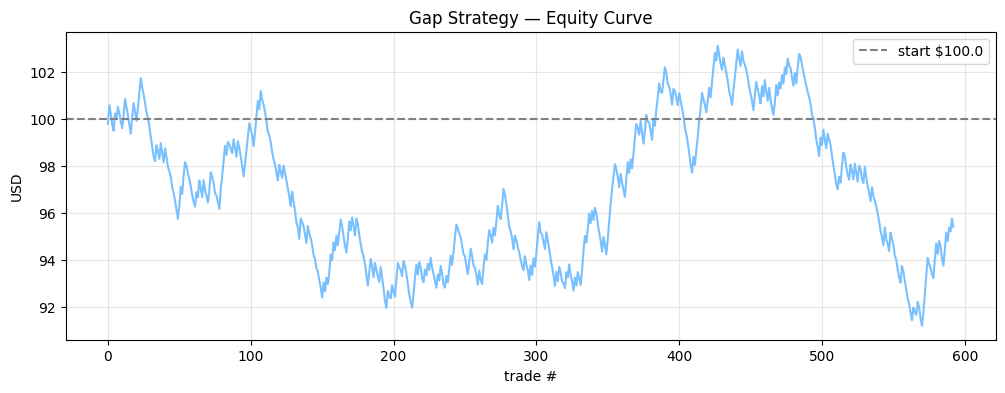


  SUMMARY
  Trades         593
  Win rate       32.9%
  Total net P&L  $-4.61
  Final equity   $95.39
  VERDICT: NO EDGE — honest result, adjust & retest

CALIBRATION  (predicted prob vs actual up-rate; close = trustworthy)
                pred    actual    n
bin                                
(0.4, 0.5]  0.482932  0.507299  274
(0.5, 0.6]  0.520606  0.527607  326


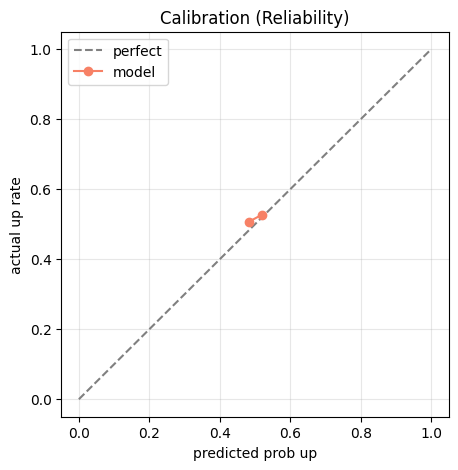

On the dashed line = honest. Bends away = over/under-confident.


In [5]:
if "trades_df" not in dir() or trades_df.empty:
    print("No trades. Lower EDGE_THRESHOLD / PERSIST_MINS, or widen minute window.")
else:
    print("RESULTS BY MINUTE")
    print(f"{'Min':>4} {'Trades':>7} {'WinRate':>8} {'TotalNet':>10}")
    print("-"*34)
    for mn in sorted(trades_df["minute"].unique()):
        g=trades_df[trades_df["minute"]==mn]
        print(f"{mn:>4} {len(g):>7} {g['won'].mean():>7.1%} {g['net'].sum():>+10.4f}")
    print("-"*34)
    tot=trades_df["net"].sum(); wr=trades_df["won"].mean()
    print(f"{'ALL':>4} {len(trades_df):>7} {wr:>7.1%} {tot:>+10.4f}")

    equity=INIT_CAPITAL+trades_df["net"].cumsum()
    plt.figure(figsize=(12,4)); plt.plot(equity.values,color="#79c0ff")
    plt.axhline(INIT_CAPITAL,ls="--",c="gray",label=f"start ${INIT_CAPITAL}")
    plt.title("Gap Strategy — Equity Curve"); plt.xlabel("trade #"); plt.ylabel("USD")
    plt.legend(); plt.grid(alpha=.3); plt.show()

    final=INIT_CAPITAL+tot
    print("\n"+"="*50); print("  SUMMARY"); print("="*50)
    print(f"  Trades         {len(trades_df)}")
    print(f"  Win rate       {wr:.1%}")
    print(f"  Total net P&L  ${tot:+.2f}")
    print(f"  Final equity   ${final:.2f}")
    print("="*50)
    if wr>0.55 and tot>0: print("  VERDICT: PROMISING — inspect closely, watch for too-few-trades")
    elif tot>0:           print("  VERDICT: MARGINAL — small edge, may be noise")
    else:                 print("  VERDICT: NO EDGE — honest result, adjust & retest")
    print("="*50)
    if wr>0.75: print("  WARNING: win rate >75% almost always means a LEAK, not edge. Investigate.")

# ── CALIBRATION CHECK (trustworthiness of the probability) ──
print("\nCALIBRATION  (predicted prob vs actual up-rate; close = trustworthy)")
bins=np.linspace(0,1,11)
test["bin"]=pd.cut(test["prob_up"],bins,include_lowest=True)
cal=test.groupby("bin",observed=True).agg(pred=("prob_up","mean"),actual=("target","mean"),n=("target","size"))
print(cal.to_string())
plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],"--",c="gray",label="perfect")
plt.plot(cal["pred"],cal["actual"],"o-",c="#f78166",label="model")
plt.xlabel("predicted prob up"); plt.ylabel("actual up rate"); plt.title("Calibration (Reliability)")
plt.legend(); plt.grid(alpha=.3); plt.show()
print("On the dashed line = honest. Bends away = over/under-confident.")

## 6 · Edge Threshold Sweep
*Test thresholds 1%-20% with the SAME leak-free, persistence logic. Find where (if anywhere) a real edge sits. No signal-flipping tricks — that only ever exploited the old leak.*

In [6]:
if mkt_df.empty:
    print("Run Section 3 first.")
else:
    def model_pred_for_window(open_unix):
        if open_unix in model_prob_by_open: return model_prob_by_open[open_unix]
        cand=[t for t in model_prob_by_open if 0<=open_unix-t<CANDLE_SECONDS]
        return model_prob_by_open[max(cand)] if cand else None

    def run_sweep(th):
        trades=[]
        for (tkr,open_unix),grp in mkt_df.groupby(["ticker","open_unix"]):
            grp=grp.sort_values("end_ts").reset_index(drop=True)
            settle=int(grp["settle"].iloc[0]); mp=model_pred_for_window(open_unix)
            if mp is None: continue
            run=0; placed=False
            for idx,row in grp.iterrows():
                minute=idx+1
                if minute<MIN_MINUTE or minute>MAX_MINUTE: continue
                crowd=float(row["crowd_prob"]); gap=mp-crowd
                run = run+1 if abs(gap)>=th else 0
                if run>=PERSIST_MINS and not placed:
                    signal=1 if gap>0 else -1
                    entry=crowd if signal==1 else (1.0-crowd); entry=min(max(entry,0.01),0.99)
                    won=(signal==1 and settle==1) or (signal==-1 and settle==0)
                    gross=(1.0-entry) if won else -entry
                    fee=round(KALSHI_FEE_MULT*entry*(1.0-entry),4)
                    trades.append({"won":int(won),"net":gross-fee}); placed=True
        if not trades: return None
        d=pd.DataFrame(trades)
        return {"th":th,"trades":len(d),"win":d["won"].mean(),"net":d["net"].sum()}

    print(f"{'Thresh':>7} {'Trades':>7} {'WinRate':>8} {'TotalNet':>10}")
    print("-"*36)
    for th in [round(x*0.01,2) for x in range(1,21)]:
        r=run_sweep(th)
        if r is None: print(f"{th*100:>6.0f}% {'--':>7}"); continue
        print(f"{th*100:>6.0f}% {r['trades']:>7} {r['win']:>7.1%} {r['net']:>+10.2f}")
    print("-"*36)
    print("Look for: positive net AND >=30 trades AND win rate 52-60% (realistic edge).")
    print("Ignore any row with win rate >70% — that is a leak signature, not edge.")

 Thresh  Trades  WinRate   TotalNet
------------------------------------
     1%     598   35.6%      -2.99
     2%     598   34.3%      -7.01
     3%     598   34.1%      -5.07
     4%     593   32.9%      -4.61
     5%     591   33.2%      +2.18
     6%     585   32.1%      +1.15
     7%     581   31.5%      +1.84
     8%     578   30.8%      +2.38
     9%     572   29.7%      +1.11
    10%     565   28.0%      -2.65
    11%     557   26.8%      -4.59
    12%     539   24.5%     -11.80
    13%     527   24.5%      -6.00
    14%     516   23.1%     -10.19
    15%     504   22.4%      -7.94
    16%     491   22.0%      -5.82
    17%     477   20.8%      -5.91
    18%     461   20.6%      -3.26
    19%     444   20.3%      -0.72
    20%     430   19.1%      -2.82
------------------------------------
Look for: positive net AND >=30 trades AND win rate 52-60% (realistic edge).
Ignore any row with win rate >70% — that is a leak signature, not edge.
